# Federated Statistics for Financial Fraud Detection
This notebook demonstrates how to compute federated statistics on financial transaction data using NVIDIA FLARE (NVFlare). It shows how to define statistical recipes, execute them in a federated environment, and visualize the results from different distributed sites.

## 0. Define User Info
Provide your local NVFlare startup kit and username information.

In [1]:
startup_kit_location = "/path/to/admin_startup_kit"
username = "admin@nvidia.com"

## 1. Define Stats Recipe

In [2]:
from src.stats.client import FinancialStatistics

from nvflare.recipe.fedstats import FedStatsRecipe
from nvflare.recipe.prod_env import ProdEnv

df_stats_generator = FinancialStatistics(
    data_path="/workspace/dataset/synthetic1", # assumes each client uses the same data path
    data_features=['amount', 'newbalanceDest', 'isFraud'], #  'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest'
) 

statistic_configs = {
    "count": {},
    "mean": {},
    "sum": {},
    "stddev": {},
    #"histogram": {"*": {"bins": 128, "range": [1, 1e6]}, "amount": {"bins": 128, "range": [0, 500e3]}, "isFraud": {"bins": 2, "range": [0, 1]}},  # pysim1
    "histogram": {"*": {"bins": 10, "range": [-1, 1]}, "isFraud": {"bins": 2, "range": [0, 1]}}, # synthetic1
    "quantile": {"*": [0.1, 0.5, 0.9]},
}

recipe = FedStatsRecipe(
    name="fedstats",
    sites=["site5"],
    statistic_configs=statistic_configs,
    stats_generator=df_stats_generator,
    stats_output_path="statistics/financial_stats.json"
)

# optionally export
recipe.export("job_configs")

## 2. Run in Production Environment

In [3]:
env = ProdEnv(startup_kit_location=startup_kit_location, username=username)
run = recipe.execute(env=env)

Connecting to FLARE ...
Submitted job 'fedstats' with ID: 9fafaf9a-fcba-4072-b2b6-555afc2c386d


### Get Status

In [4]:
print("Job Status is:", run.get_status())

Connecting to FLARE ...
Job Status is: RUNNING


### Get Results

In [5]:
result_path = run.get_result()
print("Result can be found in:", result_path)

Connecting to FLARE ...
Job ID:  9fafaf9a-fcba-4072-b2b6-555afc2c386d
Job Meta:  {'name': 'fedstats', 'resource_spec': {}, 'min_clients': 1, 'deploy_map': {'app_server': ['server'], 'app_site5': ['site5']}, 'byoc': True, 'submitter_name': 'admin@nvidia.com', 'submitter_org': 'nvidia', 'submitter_role': 'project_admin', 'job_folder_name': 'fedstats', 'job_id': '9fafaf9a-fcba-4072-b2b6-555afc2c386d', 'submit_time': 1758206307.6456137, 'submit_time_iso': '2025-09-18T14:38:27.645614+00:00', 'start_time': '2025-09-18 14:38:29.701067', 'duration': 'N/A', 'data_storage_format': 2, 'status': 'RUNNING', 'job_deploy_detail': ['server: OK', 'site5: OK'], 'schedule_count': 1, 'last_schedule_time': 1758206308.406136, 'schedule_history': ['2025-09-18 14:38:28: scheduled']}
.....
{'name': 'fedstats', 'resource_spec': {}, 'min_clients': 1, 'deploy_map': {'app_server': ['server'], 'app_site5': ['site5']}, 'byoc': True, 'submitter_name': 'admin@nvidia.com', 'submitter_org': 'nvidia', 'submitter_role': '

## 3. Show stats

In [6]:
stats_file = result_path + '/workspace/statistics/financial_stats.json'
!head -c 200 {stats_file}

{"amount": {"count": {"site5": {"train": 800, "test": 200}, "Global": {"train": 800, "test": 200}}, "mean": {"site5": {"train": 0.0409, "test": -0.1446}, "Global": {"train": 0.0409, "test": -0.1446}},

In [7]:
import json

from nvflare.app_opt.statistics.visualization.statistics_visualization import Visualization

with open(stats_file, 'r') as f:
    data = json.load(f)

### Overall stats

In [8]:
vis = Visualization()
vis.show_stats(data = data)


amount



,count,mean,sum,quantile,stddev,histogram
site5-train,800,0.0409,32.732,"{'0.1': -1.2094, '0.5': 0.0531, '0.9': 1.2775}",0.9844,"[[-1.0, -0.8, 40], [-0.8, -0.6, 47], [-0.6, -0..."
site5-test,200,-0.1446,-28.911,"{'0.1': -1.4489, '0.5': -0.1325, '0.9': 1.1412}",0.9765,"[[-1.0, -0.8, 12], [-0.8, -0.6, 10], [-0.6, -0..."
Global-train,800,0.0409,32.732,"{'0.1': -1.2094, '0.5': 0.0531, '0.9': 1.2775}",0.9844,"[[-1.0, -0.8, 40], [-0.8, -0.6, 47], [-0.6, -0..."
Global-test,200,-0.1446,-28.911,"{'0.1': -1.4489, '0.5': -0.1325, '0.9': 1.1412}",0.9765,"[[-1.0, -0.8, 12], [-0.8, -0.6, 10], [-0.6, -0..."



newbalanceDest



,count,mean,sum,quantile,stddev,histogram
site5-train,800,-0.0453,-36.2154,"{'0.1': -1.3318, '0.5': -0.0563, '0.9': 1.2414}",0.9796,"[[-1.0, -0.8, 51], [-0.8, -0.6, 50], [-0.6, -0..."
site5-test,200,-0.0088,-1.7598,"{'0.1': -1.3834, '0.5': -0.0081, '0.9': 1.376}",1.0658,"[[-1.0, -0.8, 11], [-0.8, -0.6, 16], [-0.6, -0..."
Global-train,800,-0.0453,-36.2154,"{'0.1': -1.3318, '0.5': -0.0563, '0.9': 1.2414}",0.9796,"[[-1.0, -0.8, 51], [-0.8, -0.6, 50], [-0.6, -0..."
Global-test,200,-0.0088,-1.7598,"{'0.1': -1.3834, '0.5': -0.0081, '0.9': 1.376}",1.0658,"[[-1.0, -0.8, 11], [-0.8, -0.6, 16], [-0.6, -0..."



isFraud



,count,mean,sum,quantile,stddev,histogram
site5-train,800,0.245,196,"{'0.1': 0.0, '0.5': 0.0, '0.9': 1.0}",0.4304,"[[0.0, 0.5, 604], [0.5, 1.0, 196]]"
site5-test,200,0.220,44,"{'0.1': 0.0, '0.5': 0.0, '0.9': 0.9918}",0.4153,"[[0.0, 0.5, 156], [0.5, 1.0, 44]]"
Global-train,800,0.245,196,"{'0.1': 0.0, '0.5': 0.0, '0.9': 1.0}",0.4303,"[[0.0, 0.5, 604], [0.5, 1.0, 196]]"
Global-test,200,0.220,44,"{'0.1': 0.0, '0.5': 0.0, '0.9': 0.9918}",0.4153,"[[0.0, 0.5, 156], [0.5, 1.0, 44]]"


## Histogram Visualization

(see [here](https://github.com/NVIDIA/NVFlare/blob/main/examples/advanced/federated-statistics/df_stats/demo/visualization.ipynb) for more display options)

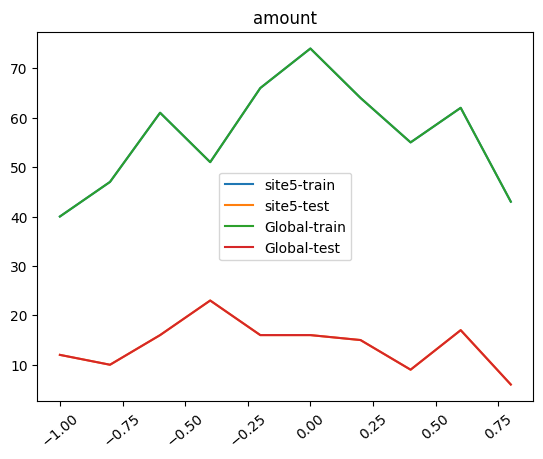

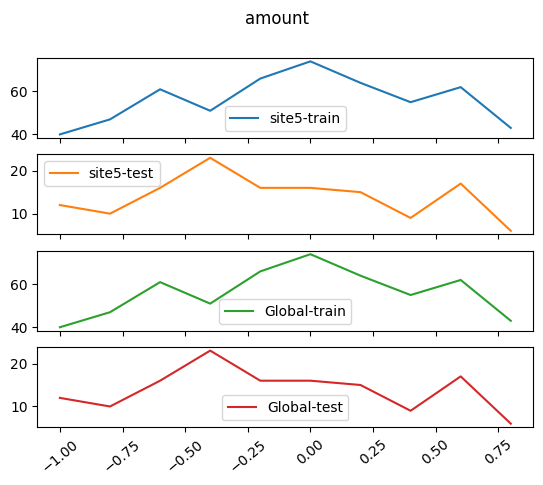

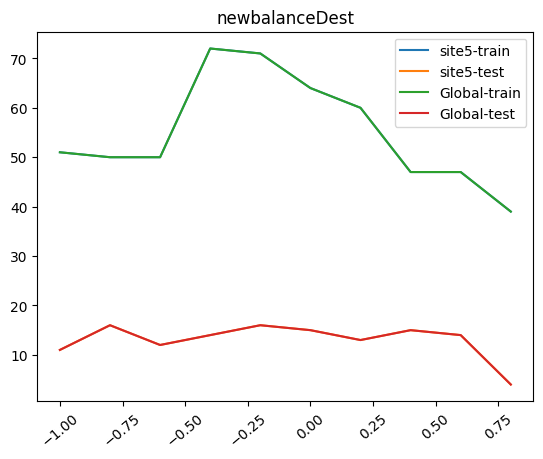

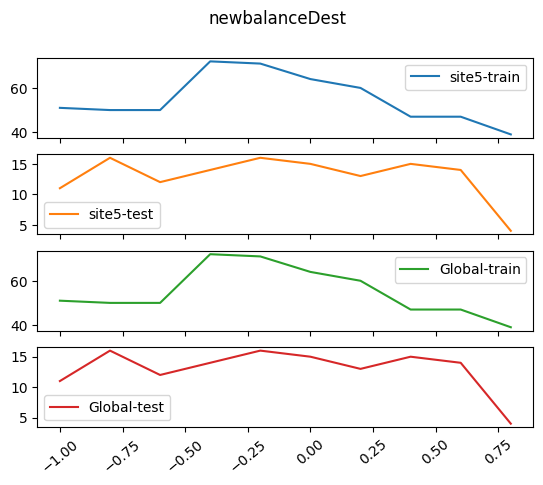

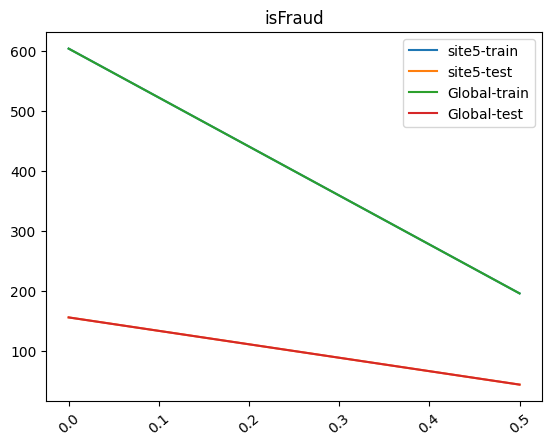

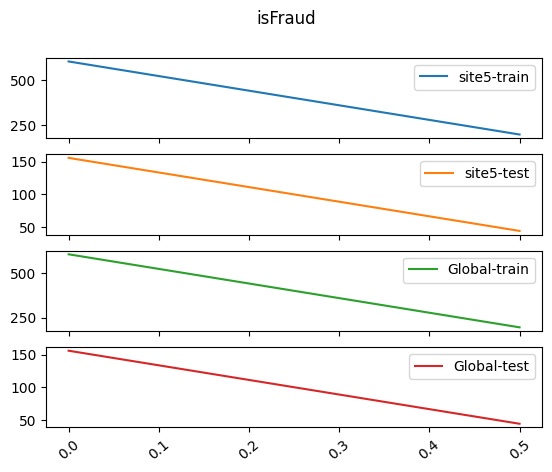

In [9]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100%  depth:100% !important; }</style>"))

vis.show_histograms(data = data) # display_format = "percent"